In [34]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RO1 = pd.read_csv('/content/RO1_Gals_2026-02-05 11-29-07.csv')
RO2 = pd.read_csv('/content/RO2_Gals_2026-02-05 11-34-28.csv')
RO3 = pd.read_csv('/content/RO3_Gals_2026-02-05 11-35-02.CSV')
RO4 = pd.read_csv('/content/RO4_2_Gals_2026-02-05 11-42-14.csv')
SE = pd.read_csv('/content/SullivansENV.csv')

In [35]:
RO4.head()

,Timestamp,Date,Time,Water_RO4_HIGH_SERVICE_FLOW_PD_Value
0,1612569600,2/6/2021,0:00:00,1.762426e+04
1,1612656000,2/7/2021,0:00:00,7.488232e+03
2,1612742400,2/8/2021,0:00:00,5.553596e+05
3,1612828800,2/9/2021,0:00:00,8.503940e+05
4,1612915200,2/10/2021,0:00:00,1.060004e+06


In [36]:
RO1['Plant_Number'] = '01'
RO2['Plant_Number'] = '02'
RO3['Plant_Number'] = '03'
RO4['Plant_Number'] = '04'

RO1.rename(columns={'Water_RO1_HIGH_SERVICE_FLOW_PD_Value': 'Flow'}, inplace = True)
RO2.rename(columns={'Water_RO2_HIGH_SERVICE_FLOW_PD_Value': 'Flow'}, inplace = True)
RO3.rename(columns={'Water_RO3_HIGH_SERVICE_FLOW_PD_Value': 'Flow'}, inplace = True)
RO4.rename(columns={'Water_RO4_HIGH_SERVICE_FLOW_PD_Value': 'Flow'}, inplace = True)

RO_Data = pd.concat([RO1, RO2, RO3, RO4])

RO_Data['Flow'] = RO_Data['Flow'].astype('int64')

RO_Data = RO_Data[['Date', 'Flow', 'Plant_Number']]

RO_Data = pd.DataFrame(RO_Data)

RO_Data.head()

,Date,Flow,Plant_Number
0,2/6/2021,519325,01
1,2/7/2021,549609,01
2,2/8/2021,526321,01
3,2/9/2021,582074,01
4,2/10/2021,531746,01


In [37]:
SE.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES,TOBS,TOBS_ATTRIBUTES
0,USC00388405,"SULLIVANS ISLAND, SC US",32.7618,-79.8573,1.5,1/2/2021,NaN,NaN,NaN,NaN,0.43,",,7,0700",71.0,",,7",55.0,",,7",56.0,",,7,0700"
1,USC00388405,"SULLIVANS ISLAND, SC US",32.7618,-79.8573,1.5,1/3/2021,NaN,NaN,NaN,NaN,0.23,",,7,0700",66.0,",,7",NaN,NaN,53.0,",,7,0700"
2,USC00388405,"SULLIVANS ISLAND, SC US",32.7618,-79.8573,1.5,1/6/2021,NaN,NaN,NaN,NaN,0.01,",,7,0700",NaN,NaN,35.0,",,7",41.0,",,7,0700"
3,USC00388405,"SULLIVANS ISLAND, SC US",32.7618,-79.8573,1.5,1/7/2021,NaN,NaN,NaN,NaN,0.00,",,7,0700",56.0,",,7",32.0,",,7",39.0,",,7,0700"
4,USC00388405,"SULLIVANS ISLAND, SC US",32.7618,-79.8573,1.5,1/8/2021,NaN,NaN,NaN,NaN,0.97,",,7,0700",59.0,",,7",39.0,",,7",41.0,",,7,0700"


In [38]:
SE['TAVG'] = SE[['TMAX', 'TMIN']].mean(axis=1)
SE = SE[['DATE', 'PRCP', 'TMAX', 'TMIN', 'TAVG']]
SE = SE.ffill()
SE_Data = pd.DataFrame(SE)
SE_Data.head(20)
SE_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    1634 non-null   object 
 1   PRCP    1634 non-null   float64
 2   TMAX    1634 non-null   float64
 3   TMIN    1634 non-null   float64
 4   TAVG    1634 non-null   float64
dtypes: float64(4), object(1)
memory usage: 64.0+ KB


In [39]:
MPW_Full = pd.merge(RO_Data, SE_Data, how="inner", left_on="Date", right_on="DATE")
#MPW_Full.to_csv("MPW_Full.csv", index = False)

In [40]:
MPW_Full['Date'] = pd.to_datetime(MPW_Full['Date'])
MPW_Full = MPW_Full.drop(columns = ['DATE'])
MPW_Full['Flow'] = MPW_Full['Flow'] / 1000
MPW_Full

,Date,Flow,Plant_Number,PRCP,TMAX,TMIN,TAVG
0,2021-02-06,519.325,01,0.08,58.0,39.0,58.0
1,2021-02-07,549.609,01,0.59,58.0,36.0,36.0
2,2021-02-10,531.746,01,0.02,66.0,36.0,66.0
3,2021-02-11,487.127,01,0.00,62.0,46.0,54.0
4,2021-02-12,545.252,01,0.03,62.0,46.0,54.0
...,...,...,...,...,...,...,...
6435,2025-12-30,860.431,04,0.00,56.0,38.0,47.0
6436,2025-12-31,890.694,04,0.00,56.0,30.0,43.0
6437,2026-01-22,1192.718,04,0.00,56.0,30.0,43.0
6438,2026-01-23,1187.425,04,0.00,55.0,49.0,52.0


In [41]:
MPW_Full['Month'] = MPW_Full['Date'].dt.month.astype(str)

MPW_Full.info()
MPW_Full.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6440 entries, 0 to 6439
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6440 non-null   datetime64[ns]
 1   Flow          6440 non-null   float64       
 2   Plant_Number  6440 non-null   object        
 3   PRCP          6440 non-null   float64       
 4   TMAX          6440 non-null   float64       
 5   TMIN          6440 non-null   float64       
 6   TAVG          6440 non-null   float64       
 7   Month         6440 non-null   object        
dtypes: datetime64[ns](1), float64(5), object(2)
memory usage: 402.6+ KB


,Date,Flow,PRCP,TMAX,TMIN,TAVG
count,6440,6440.000000,6440.000000,6440.000000,6440.000000,6440.000000
mean,2023-08-26 16:49:47.329192448,813.092986,0.139311,73.598137,60.413665,67.116149
min,2021-02-06 00:00:00,0.000000,0.000000,31.000000,19.000000,25.000000
25%,2022-07-15 00:00:00,508.948250,0.000000,65.000000,50.000000,57.000000
50%,2023-09-09 12:00:00,753.763000,0.000000,75.000000,63.000000,69.000000
75%,2024-10-16 00:00:00,1090.660000,0.030000,84.000000,72.000000,78.500000
max,2026-01-24 00:00:00,3385.108000,6.530000,96.000000,85.000000,94.000000
std,NaN,468.677249,0.421861,12.336459,13.506385,12.721021


In [42]:
# Season: 1, 2, 3, 4. Spring, Summer, Fall, Winter
# Temperature: 1, 2, 3. Cold, Warm, Hot
# Rain: 0, 1. No Rain, Rain
# Flow_Rate: 1, 2, 3. Low, Medium, High

In [43]:
MPW_Full['Season'] = np.where(MPW_Full['Month'].isin(["12", "1", "2"]), '4',
                              np.where(MPW_Full['Month'].isin(["3", "4", "5"]), '1',
                                       np.where(MPW_Full['Month'].isin(["6", "7", "8"]), '2',
                                                '3'))).astype('int64')
MPW_Full.head()

,Date,Flow,Plant_Number,PRCP,TMAX,TMIN,TAVG,Month,Season
0,2021-02-06,519.325,01,0.08,58.0,39.0,58.0,2,4
1,2021-02-07,549.609,01,0.59,58.0,36.0,36.0,2,4
2,2021-02-10,531.746,01,0.02,66.0,36.0,66.0,2,4
3,2021-02-11,487.127,01,0.00,62.0,46.0,54.0,2,4
4,2021-02-12,545.252,01,0.03,62.0,46.0,54.0,2,4


In [44]:
# Rain is based on a threshold created by the daily average rainfall in this area from 1991 to 2020, 0.14 inches.
# Temperature is based on a threshold created by the average annual temperature of the same source, 67 F.
# A 18 degree buffer is created on both sides to create the ranges of cold, warm, hot. This was created
# by finding the difference between the avg and freezing (32 F), 35 F, and the avg and 100 F, 38.
# The mid point between these differences is 36 F, and alloting for a 36 degree buffer causes 18 degrees on both sides.
# This method may not be the best for individual peoples definition of "warm" but it is definable.
MPW_Full['Rain'] = np.where(MPW_Full['PRCP'] >= 0.14, '1', '0').astype('int64')
MPW_Full['Temperature'] = np.where(MPW_Full['TAVG'] >= 85, '3',
                                   np.where(MPW_Full['TAVG'] >= 49, '2', '1')).astype('int64')
MPW_Full['TempMax'] = np.where(MPW_Full['TMAX'] >= 85, '3',
                                   np.where(MPW_Full['TMAX'] >= 49, '2', '1')).astype('int64')
MPW_Full['TempMin'] = np.where(MPW_Full['TMIN'] >= 85, '3',
                                   np.where(MPW_Full['TMIN'] >= 49, '2', '1')).astype('int64')

In [45]:
MPW_Full['Days_Since_Rain'] = MPW_Full.apply(lambda x: np.argmax(MPW_Full.iloc[x.name::-1].Rain.tolist()), axis=1)
MPW_Full['Days_Since_Rain'] = np.where(MPW_Full['Days_Since_Rain'] > 3, 3, MPW_Full['Days_Since_Rain']).astype('int64')

MPW_Full['Flow'].describe().apply(lambda x: format(x, '0.0f'))

MPW_Full.head(20)

,Date,Flow,Plant_Number,PRCP,TMAX,TMIN,TAVG,Month,Season,Rain,Temperature,TempMax,TempMin,Days_Since_Rain
0,2021-02-06,519.325,01,0.08,58.0,39.0,58.0,2,4,0,2,2,1,0
1,2021-02-07,549.609,01,0.59,58.0,36.0,36.0,2,4,1,1,2,1,0
2,2021-02-10,531.746,01,0.02,66.0,36.0,66.0,2,4,0,2,2,1,1
3,2021-02-11,487.127,01,0.00,62.0,46.0,54.0,2,4,0,2,2,1,2
4,2021-02-12,545.252,01,0.03,62.0,46.0,54.0,2,4,0,2,2,1,3
5,2021-02-17,532.492,01,0.03,62.0,46.0,54.0,2,4,0,2,2,1,3
6,2021-02-18,440.451,01,0.00,62.0,46.0,54.0,2,4,0,2,2,1,3
7,2021-02-19,380.484,01,0.10,59.0,39.0,49.0,2,4,0,2,2,1,3
8,2021-02-20,256.532,01,0.27,59.0,35.0,35.0,2,4,1,1,2,1,0
9,2021-02-21,493.290,01,0.32,59.0,33.0,33.0,2,4,1,1,2,1,0


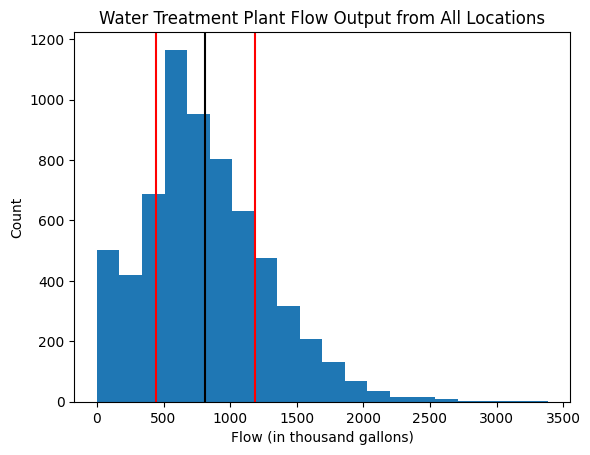

In [46]:
Full_LPerc = MPW_Full['Flow'].quantile(0.20)
Full_HPerc = MPW_Full['Flow'].quantile(0.80)
Full_MPerc = MPW_Full['Flow'].mean()

plt.hist(MPW_Full['Flow'], bins = 20)
plt.title('Water Treatment Plant Flow Output from All Locations')
plt.xlabel('Flow (in thousand gallons)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(Full_LPerc, color='red')
plt.axvline(Full_HPerc, color='red')
plt.axvline(Full_MPerc, color='black')

In [47]:
# Mistake switch LPerc and HPerc which then split the data into only two sections around quantile 0.25
MPW_Full['Flow_Rate3'] = np.where(MPW_Full['Flow'] >= Full_HPerc, "2",
                                  np.where(MPW_Full['Flow'] >= Full_LPerc, "1", "0")).astype('int64')
MPW_Full['Flow_Rate2'] = np.where(MPW_Full['Flow'] >= Full_MPerc, "1", "0").astype('int64')

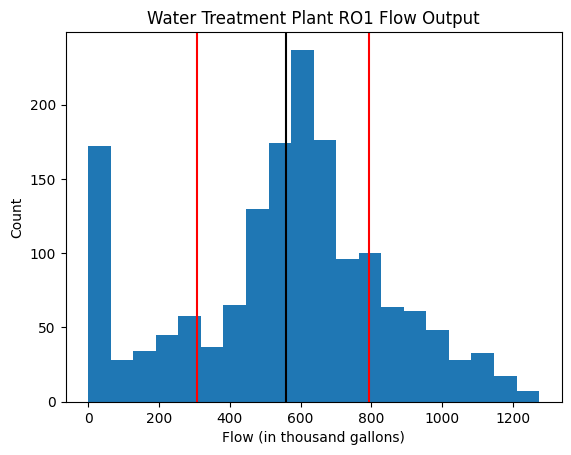

In [48]:
RO1 = MPW_Full[MPW_Full['Plant_Number'] == '01']
RO1_LPerc = RO1['Flow'].quantile(0.20)
RO1_HPerc = RO1['Flow'].quantile(0.80)
RO1_MPerc = RO1['Flow'].mean()

plt.hist(RO1['Flow'], bins = 20)
plt.title('Water Treatment Plant RO1 Flow Output')
plt.xlabel('Flow (in thousand gallons)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(RO1_LPerc, color='red')
plt.axvline(RO1_HPerc, color='red')
plt.axvline(RO1_MPerc, color='black')

In [49]:
RO1['RO1_Flow3'] = np.where(RO1['Flow'] >= RO1_HPerc, "2",
                                  np.where(RO1['Flow'] >= RO1_LPerc, "1", "0")).astype('int64')
RO1['RO1_Flow2'] = np.where(RO1['Flow'] >= RO1_MPerc, "1", "0").astype('int64')

/tmp/ipykernel_24655/2096850535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO1['RO1_Flow3'] = np.where(RO1['Flow'] >= RO1_HPerc, "2",
/tmp/ipykernel_24655/2096850535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO1['RO1_Flow2'] = np.where(RO1['Flow'] >= RO1_MPerc, "1", "0").astype('int64')


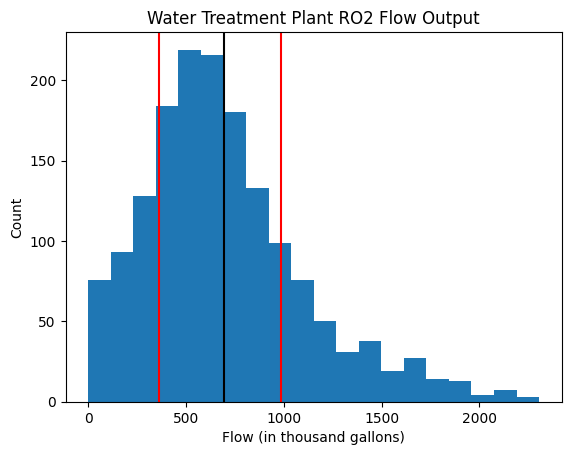

In [50]:
RO2 = MPW_Full[MPW_Full['Plant_Number'] == '02']
RO2_LPerc = RO2['Flow'].quantile(0.20)
RO2_HPerc = RO2['Flow'].quantile(0.80)
RO2_MPerc = RO2['Flow'].mean()

plt.hist(RO2['Flow'], bins = 20)
plt.title('Water Treatment Plant RO2 Flow Output')
plt.xlabel('Flow (in thousand gallons)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(RO2_LPerc, color='red')
plt.axvline(RO2_HPerc, color='red')
plt.axvline(RO2_MPerc, color='black')

In [51]:
RO2['RO2_Flow3'] = np.where(RO2['Flow'] >= RO2_HPerc, "2",
                                  np.where(RO2['Flow'] >= RO2_LPerc, "1", "0")).astype('int64')
RO2['RO2_Flow2'] = np.where(RO2['Flow'] >= RO2_MPerc, "1", "0").astype('int64')

/tmp/ipykernel_24655/3507570930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO2['RO2_Flow3'] = np.where(RO2['Flow'] >= RO2_HPerc, "2",
/tmp/ipykernel_24655/3507570930.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO2['RO2_Flow2'] = np.where(RO2['Flow'] >= RO2_MPerc, "1", "0").astype('int64')


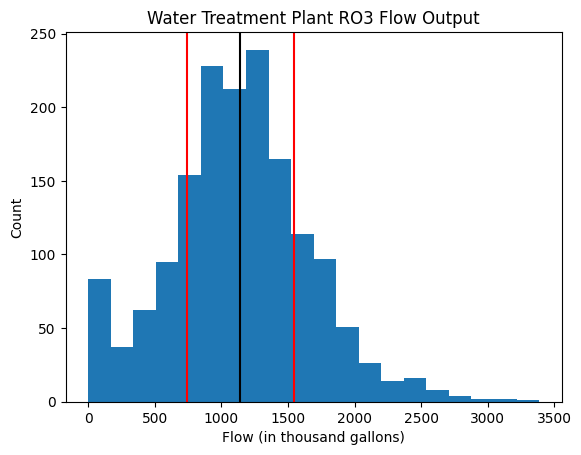

In [52]:
RO3 = MPW_Full[MPW_Full['Plant_Number'] == '03']
RO3_LPerc = RO3['Flow'].quantile(0.20)
RO3_HPerc = RO3['Flow'].quantile(0.80)
RO3_MPerc = RO3['Flow'].mean()

plt.hist(RO3['Flow'], bins = 20)
plt.title('Water Treatment Plant RO3 Flow Output')
plt.xlabel('Flow (in thousand gallons)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(RO3_LPerc, color='red')
plt.axvline(RO3_HPerc, color='red')
plt.axvline(RO3_MPerc, color='black')

In [53]:
RO3['RO3_Flow3'] = np.where(RO3['Flow'] >= RO3_HPerc, "2",
                                  np.where(RO3['Flow'] >= RO3_LPerc, "1", "0")).astype('int64')
RO3['RO3_Flow2'] = np.where(RO3['Flow'] >= RO3_MPerc, "1", "0").astype('int64')

/tmp/ipykernel_24655/1096891906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO3['RO3_Flow3'] = np.where(RO3['Flow'] >= RO3_HPerc, "2",
/tmp/ipykernel_24655/1096891906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO3['RO3_Flow2'] = np.where(RO3['Flow'] >= RO3_MPerc, "1", "0").astype('int64')


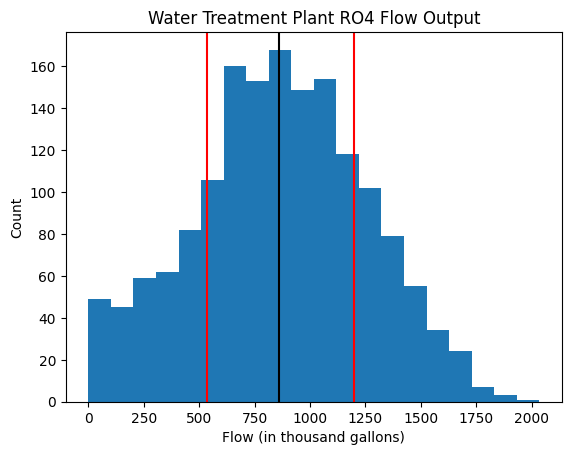

In [54]:
RO4 = MPW_Full[MPW_Full['Plant_Number'] == '04']
RO4_LPerc = RO4['Flow'].quantile(0.20)
RO4_HPerc = RO4['Flow'].quantile(0.80)
RO4_MPerc = RO4['Flow'].mean()

plt.hist(RO4['Flow'], bins = 20)
plt.title('Water Treatment Plant RO4 Flow Output')
plt.xlabel('Flow (in thousand gallons)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(RO4_LPerc, color='red')
plt.axvline(RO4_HPerc, color='red')
plt.axvline(RO4_MPerc, color='black')

In [55]:
RO4['RO4_Flow3'] = np.where(RO4['Flow'] >= RO4_HPerc, "2",
                                  np.where(RO4['Flow'] >= RO4_LPerc, "1", "0")).astype('int64')
RO4['RO4_Flow2'] = np.where(RO4['Flow'] >= RO4_MPerc, "1", "0").astype('int64')
RO4

/tmp/ipykernel_24655/1672254253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO4['RO4_Flow3'] = np.where(RO4['Flow'] >= RO4_HPerc, "2",
/tmp/ipykernel_24655/1672254253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RO4['RO4_Flow2'] = np.where(RO4['Flow'] >= RO4_MPerc, "1", "0").astype('int64')


,Date,Flow,Plant_Number,PRCP,TMAX,TMIN,TAVG,Month,Season,Rain,Temperature,TempMax,TempMin,Days_Since_Rain,Flow_Rate3,Flow_Rate2,RO4_Flow3,RO4_Flow2
4830,2021-02-06,17.624,04,0.08,58.0,39.0,58.0,2,4,0,2,2,1,3,0,0,0,0
4831,2021-02-07,7.488,04,0.59,58.0,36.0,36.0,2,4,1,1,2,1,0,0,0,0,0
4832,2021-02-10,1060.003,04,0.02,66.0,36.0,66.0,2,4,0,2,2,1,1,1,1,1,1
4833,2021-02-11,969.267,04,0.00,62.0,46.0,54.0,2,4,0,2,2,1,2,1,1,1,1
4834,2021-02-12,617.853,04,0.03,62.0,46.0,54.0,2,4,0,2,2,1,3,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6435,2025-12-30,860.431,04,0.00,56.0,38.0,47.0,12,4,0,1,2,1,3,1,1,1,0
6436,2025-12-31,890.694,04,0.00,56.0,30.0,43.0,12,4,0,1,2,1,3,1,1,1,1
6437,2026-01-22,1192.718,04,0.00,56.0,30.0,43.0,1,4,0,1,2,1,3,2,1,1,1
6438,2026-01-23,1187.425,04,0.00,55.0,49.0,52.0,1,4,0,2,2,2,3,2,1,1,1


In [56]:
MPW_Model = MPW_Full
MPW_Model = pd.DataFrame(MPW_Model)
MPW_Model.info()
MPW_Model = MPW_Model[["Flow_Rate3", "Flow_Rate2", "Month", "Season", "Temperature", "TempMax", "TempMin", "Rain", "Days_Since_Rain"]]
print(" ")
RO1_Model = pd.DataFrame(RO1)
RO1_Model.info()
RO1_Model = RO1_Model[["RO1_Flow3", "RO1_Flow2", "Month", "Season", "Temperature", "TempMax", "TempMin", "Rain", "Days_Since_Rain"]]
print(" ")
RO2_Model = pd.DataFrame(RO2)
RO2_Model.info()
RO2_Model = RO2_Model[["RO2_Flow3", "RO2_Flow2", "Month", "Season", "Temperature", "TempMax", "TempMin", "Rain", "Days_Since_Rain"]]
print(" ")
RO3_Model = pd.DataFrame(RO3)
RO3_Model.info()
RO3_Model = RO3_Model[["RO3_Flow3", "RO3_Flow2", "Month", "Season", "Temperature", "TempMax", "TempMin", "Rain", "Days_Since_Rain"]]
print(" ")
RO4_Model = pd.DataFrame(RO4)
RO4_Model.info()
RO4_Model = RO4_Model[["RO4_Flow3", "RO4_Flow2", "Month", "Season", "Temperature", "TempMax", "TempMin", "Rain", "Days_Since_Rain"]]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6440 entries, 0 to 6439
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             6440 non-null   datetime64[ns]
 1   Flow             6440 non-null   float64       
 2   Plant_Number     6440 non-null   object        
 3   PRCP             6440 non-null   float64       
 4   TMAX             6440 non-null   float64       
 5   TMIN             6440 non-null   float64       
 6   TAVG             6440 non-null   float64       
 7   Month            6440 non-null   object        
 8   Season           6440 non-null   int64         
 9   Rain             6440 non-null   int64         
 10  Temperature      6440 non-null   int64         
 11  TempMax          6440 non-null   int64         
 12  TempMin          6440 non-null   int64         
 13  Days_Since_Rain  6440 non-null   int64         
 14  Flow_Rate3       6440 non-null   int64  

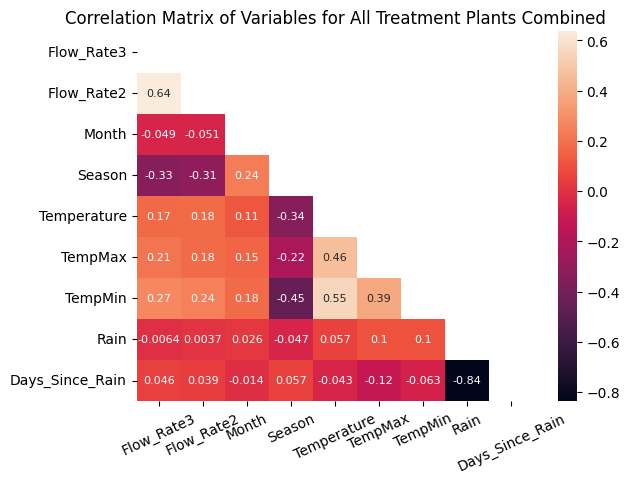

In [57]:
sns.heatmap(MPW_Model.corr(), annot=True, annot_kws={"fontsize":8},
            mask = np.triu(np.ones_like(MPW_Model.corr())))
plt.tick_params(axis='x', labelrotation=25)
plt.title('Correlation Matrix of Variables for All Treatment Plants Combined')
# Chose Season, TempMin
MPW_Model = MPW_Model[["Season", "Flow_Rate3", "Flow_Rate2"]]

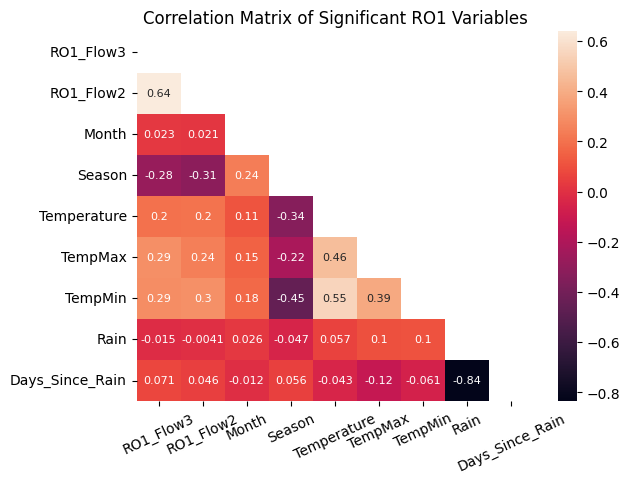

In [58]:
sns.heatmap(RO1_Model.corr(), annot=True, annot_kws={"size":8},
            mask = np.triu(np.ones_like(RO1_Model.corr())))
plt.title('Correlation Matrix of Significant RO1 Variables')
plt.tick_params(axis='x', labelrotation=25)
# Chose Season, TempMax, TempMin
RO1_Model = RO1_Model[["Season", "RO1_Flow3", "RO1_Flow2"]]

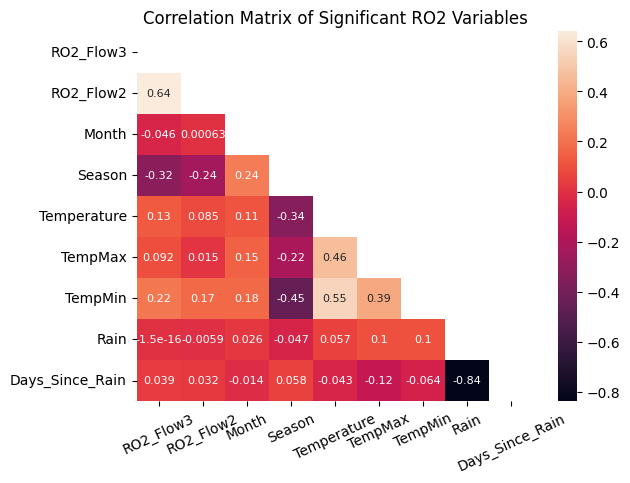

In [59]:
sns.heatmap(RO2_Model.corr(), annot=True, annot_kws={"size":8},
            mask = np.triu(np.ones_like(RO2_Model.corr())))
plt.title('Correlation Matrix of Significant RO2 Variables')
plt.tick_params(axis='x', labelrotation=25)
# Chose Season, TempMin
RO2_Model = RO2_Model[["Season", "RO2_Flow3", "RO2_Flow2"]]

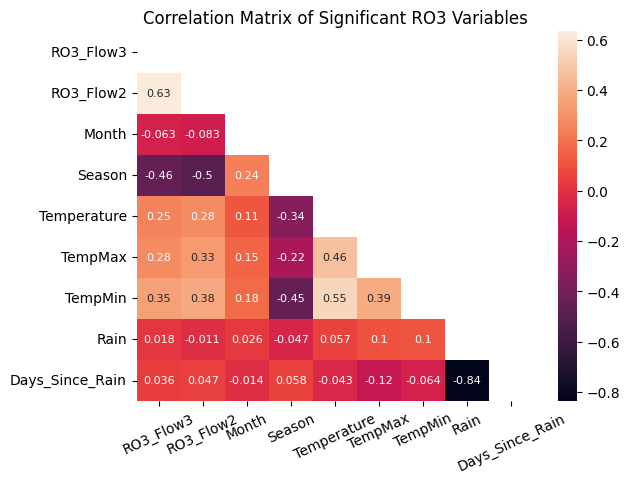

In [60]:
sns.heatmap(RO3_Model.corr(), annot=True, annot_kws={"size":8},
            mask = np.triu(np.ones_like(RO3_Model.corr())))
plt.title('Correlation Matrix of Significant RO3 Variables')
plt.tick_params(axis='x', labelrotation=25)
# Chose Season, Temperature, TempMax, TempMin
RO3_Model = RO3_Model[["Season", "RO3_Flow3", "RO3_Flow2"]]

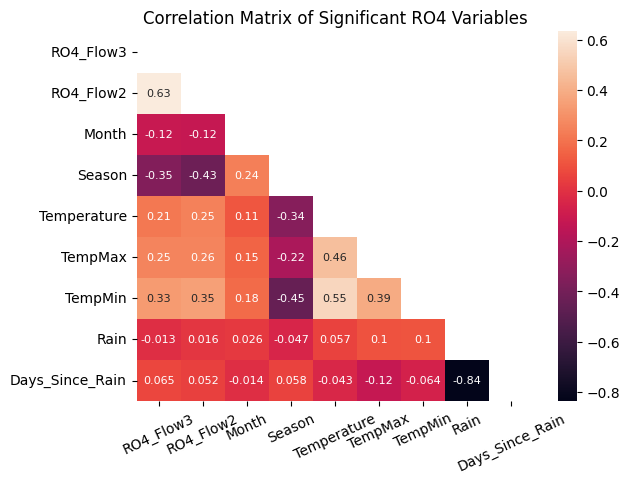

In [61]:
sns.heatmap(RO4_Model.corr(), annot=True, annot_kws={"size":8},
            mask = np.triu(np.ones_like(RO4_Model.corr())))
plt.title('Correlation Matrix of Significant RO4 Variables')
plt.tick_params(axis='x', labelrotation=25)
# Chose Season
RO4_Model = RO4_Model[["Season", "RO4_Flow3", "RO4_Flow2"]]

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier, XGBRegressor

In [66]:
X = MPW_Model.drop(['Flow_Rate3', 'Flow_Rate2'], axis = 1)
y = MPW_Model['Flow_Rate2']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.6510093167701864
0.6537267080745341
 
SVC
0.6510093167701864
0.6537267080745341
 
KNN
0.6104425465838509
0.6234472049689441
 
DecisionTreeClassifier
0.6510093167701864
0.6537267080745341
 
cross_val_score
[0.67701863 0.54192547 0.58074534 0.73757764 0.72049689]
0.65 accuracy with a standard deviation of 0.08
 
ShuffleSplit
[0.6573499  0.65942029 0.65217391 0.6552795  0.65062112]
0.65 accuracy with a standard deviation of 0.00
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       714
           1       0.60      0.69      0.64       574

    accuracy                           0.65      1288
   macro avg       0.66      0.66      0.65      1288
weighted avg       0.66      0.65      0.65      1288



In [65]:
X = MPW_Model.drop(['Flow_Rate3', 'Flow_Rate2'], axis = 1)
y = MPW_Model['Flow_Rate3']

print('Full')
print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Full
Logistic Regression
0.6057841614906833
0.5768633540372671
 
SVC
0.6057841614906833
0.5768633540372671
 
KNN
0.5518245341614907
0.5357142857142857
 
DecisionTreeClassifier
0.6057841614906833
0.5768633540372671
 
cross_val_score
[0.60015528 0.60015528 0.60015528 0.60015528 0.59937888]
0.60 accuracy with a standard deviation of 0.00
 
ShuffleSplit
[0.59937888 0.59679089 0.60351967 0.58385093 0.59886128]
0.60 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       281
           1       0.58      1.00      0.73       743
           2       0.00      0.00      0.00       264

    accuracy                           0.58      1288
   macro avg       0.19      0.33      0.24      1288
weighted avg       0.33      0.58      0.42      1288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [68]:
X = RO1_Model.drop(['RO1_Flow3', 'RO1_Flow2'], axis = 1)
y = RO1_Model['RO1_Flow2']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.6909937888198758
0.6770186335403726
 
SVC
0.6909937888198758
0.6770186335403726
 
KNN
0.6513975155279503
0.6894409937888198
 
DecisionTreeClassifier
0.6909937888198758
0.6770186335403726
 
cross_val_score
[0.70496894 0.72981366 0.77950311 0.45962733 0.76708075]
0.69 accuracy with a standard deviation of 0.12
 
ShuffleSplit
[0.65838509 0.70807453 0.66873706 0.6873706  0.65217391]
0.67 accuracy with a standard deviation of 0.02
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.75      0.46      0.57       149
           1       0.65      0.87      0.74       173

    accuracy                           0.68       322
   macro avg       0.70      0.66      0.65       322
weighted avg       0.69      0.68      0.66       322



In [67]:
X = RO1_Model.drop(['RO1_Flow3', 'RO1_Flow2'], axis = 1)
y = RO1_Model['RO1_Flow3']
print("RO1_Model")

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

RO1_Model
Logistic Regression
0.6024844720496895
0.5900621118012422
 
SVC
0.6024844720496895
0.5900621118012422
 
KNN
0.5566770186335404
0.5559006211180124
 
DecisionTreeClassifier
0.6024844720496895
0.5900621118012422
 
cross_val_score
[0.60248447 0.59937888 0.59937888 0.59937888 0.59937888]
0.60 accuracy with a standard deviation of 0.00
 
ShuffleSplit
[0.60662526 0.61490683 0.60041408 0.5942029  0.58592133]
0.60 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.59      1.00      0.74       190
           2       0.00      0.00      0.00        59

    accuracy                           0.59       322
   macro avg       0.20      0.33      0.25       322
weighted avg       0.35      0.59      0.44       322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
X = RO2_Model.drop(['RO2_Flow3', 'RO2_Flow2'], axis = 1)
y = RO2_Model['RO2_Flow2']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.5877329192546584
0.6242236024844721
 
SVC
0.593944099378882
0.6180124223602484
 
KNN
0.5698757763975155
0.5838509316770186
 
DecisionTreeClassifier
0.593944099378882
0.6180124223602484
 
cross_val_score
[0.54347826 0.39130435 0.57142857 0.5621118  0.66770186]
0.55 accuracy with a standard deviation of 0.09
 
ShuffleSplit
[0.61904762 0.61283644 0.59627329 0.61283644 0.63146998]
0.61 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       188
           1       0.53      0.63      0.58       134

    accuracy                           0.62       322
   macro avg       0.62      0.62      0.61       322
weighted avg       0.63      0.62      0.62       322



In [69]:
X = RO2_Model.drop(['RO2_Flow3', 'RO2_Flow2'], axis = 1)
y = RO2_Model['RO2_Flow3']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.6110248447204969
0.5559006211180124
 
SVC
0.6110248447204969
0.5559006211180124
 
KNN
0.6110248447204969
0.5559006211180124
 
DecisionTreeClassifier
0.6110248447204969
0.5559006211180124
 
cross_val_score
[0.60248447 0.59937888 0.59937888 0.59937888 0.59937888]
0.60 accuracy with a standard deviation of 0.00
 
ShuffleSplit
[0.59627329 0.59006211 0.60248447 0.61283644 0.60662526]
0.60 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        75
           1       0.56      1.00      0.71       179
           2       0.00      0.00      0.00        68

    accuracy                           0.56       322
   macro avg       0.19      0.33      0.24       322
weighted avg       0.31      0.56      0.40       322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
X = RO3_Model.drop(['RO3_Flow3', 'RO3_Flow2'], axis = 1)
y = RO3_Model['RO3_Flow2']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.7678571428571429
0.7422360248447205
 
SVC
0.7678571428571429
0.7422360248447205
 
KNN
0.6692546583850931
0.6521739130434783
 
DecisionTreeClassifier
0.7678571428571429
0.7422360248447205
 
cross_val_score
[0.77950311 0.69254658 0.54347826 0.76086957 0.81055901]
0.72 accuracy with a standard deviation of 0.10
 
ShuffleSplit
[0.67080745 0.70807453 0.74741201 0.69979296 0.70807453]
0.71 accuracy with a standard deviation of 0.02
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       172
           1       0.71      0.75      0.73       150

    accuracy                           0.74       322
   macro avg       0.74      0.74      0.74       322
weighted avg       0.74      0.74      0.74       322



In [71]:
X = RO3_Model.drop(['RO3_Flow3', 'RO3_Flow2'], axis = 1)
y = RO3_Model['RO3_Flow3']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.5978260869565217
0.5714285714285714
 
SVC
0.5978260869565217
0.5714285714285714
 
KNN
0.42391304347826086
0.531055900621118
 
DecisionTreeClassifier
0.5978260869565217
0.5714285714285714
 
cross_val_score
[0.60248447 0.59937888 0.59937888 0.59937888 0.59937888]
0.60 accuracy with a standard deviation of 0.00
 
ShuffleSplit
[0.61283644 0.63354037 0.62111801 0.59627329 0.61490683]
0.62 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.36      0.66      0.47        50
           1       0.65      0.72      0.69       209
           2       0.00      0.00      0.00        63

    accuracy                           0.57       322
   macro avg       0.34      0.46      0.38       322
weighted avg       0.48      0.57      0.52       322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
X = RO4_Model.drop(['RO4_Flow3', 'RO4_Flow2'], axis = 1)
y = RO4_Model['RO4_Flow2']
print("RO1_Model")

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

RO1_Model
Logistic Regression
0.734472049689441
0.7142857142857143
 
SVC
0.734472049689441
0.7142857142857143
 
KNN
0.734472049689441
0.7142857142857143
 
DecisionTreeClassifier
0.734472049689441
0.7142857142857143
 
cross_val_score
[0.77018634 0.76397516 0.67701863 0.64906832 0.79192547]
0.73 accuracy with a standard deviation of 0.06
 
ShuffleSplit
[0.71221532 0.72670807 0.75569358 0.70600414 0.74120083]
0.73 accuracy with a standard deviation of 0.02
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       167
           1       0.70      0.72      0.71       155

    accuracy                           0.71       322
   macro avg       0.71      0.71      0.71       322
weighted avg       0.71      0.71      0.71       322



In [73]:
X = RO4_Model.drop(['RO4_Flow3', 'RO4_Flow2'], axis = 1)
y = RO4_Model['RO4_Flow3']

print("Logistic Regression")
cls = LogisticRegression(max_iter = 1000, random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("SVC")
cls = svm.SVC()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("KNN")
cls = KNeighborsClassifier(n_neighbors = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("DecisionTreeClassifier")
cls = DecisionTreeClassifier(random_state=44)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(" ")

print("cross_val_score")
clf = svm.SVC(kernel='linear', C=1, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))
print(" ")

print("ShuffleSplit")
n_samples = X.shape[0]
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
score = cross_val_score(clf, X, y, cv=cv)
print(score)
print("%0.2f accuracy with a standard deviation of %0.2f" % (score.mean(), score.std()))

print("XGBoost Classifier")
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Logistic Regression
0.6017080745341615
0.593167701863354
 
SVC
0.6017080745341615
0.593167701863354
 
KNN
0.6017080745341615
0.593167701863354
 
DecisionTreeClassifier
0.6017080745341615
0.593167701863354
 
cross_val_score
[0.59937888 0.59937888 0.60248447 0.59937888 0.59937888]
0.60 accuracy with a standard deviation of 0.00
 
ShuffleSplit
[0.61697723 0.60869565 0.59834369 0.60455487 0.6252588 ]
0.61 accuracy with a standard deviation of 0.01
XGBoost Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        63
           1       0.59      1.00      0.74       191
           2       0.00      0.00      0.00        68

    accuracy                           0.59       322
   macro avg       0.20      0.33      0.25       322
weighted avg       0.35      0.59      0.44       322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
